# GEO Satellite Orbital Behavior Analysis
Gabriel Casarotto

Date: 11/03/2026

### Data Analysis:
In this notebook, we perform an exploratory analysis of a dataset containing the TLE history of several satellites since 2020. Based on rigorous astrodynamics principles, we will evaluate the operational status of these objects. Specifically, we will track the **Longitude** to observe East-West station-keeping and the **Inclination** to observe North-South station-keeping.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from sgp4.api import Satrec
from skyfield.api import EarthSatellite, load
import warnings

# Ignore skyfield warnings about old TLEs for cleaner output
warnings.filterwarnings('ignore')

# 1. Load the dataset generated via the Space-Track API
df = pd.read_csv('mon_dataset_geo.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Dataset loaded. Total rows: {len(df)}")

Dataset loaded. Total rows: 123234


In [3]:
# convert the 'date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# removal of microseconds for a more readable display
df['date'] = df['date'].dt.floor('s')

df.head()

,norad_id,date,line1,line2
0,25546,2020-01-01 18:32:50,1 25546U 98068A 20001.77281198 -.00000071 +0...,2 25546 006.0044 062.8088 0006548 287.4973 127...
1,25546,2020-01-02 02:41:42,1 25546U 98068A 20002.11229626 -.00000060 0...,2 25546 6.0051 62.8073 0006553 287.5980 248...
2,25546,2020-01-02 16:13:02,1 25546U 98068A 20002.67571962 -.00000042 +0...,2 25546 006.0062 062.8048 0006578 287.8198 089...
3,25546,2020-01-03 16:18:59,1 25546U 98068A 20003.67985098 -.00000012 +0...,2 25546 006.0081 062.8002 0006602 288.1736 086...
4,25546,2020-01-04 16:59:56,1 25546U 98068A 20004.70829160 .00000016 0...,2 25546 6.0101 62.7956 0006627 288.5308 93...


I look at the general information in my dataframe.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123234 entries, 0 to 123233
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   norad_id  123234 non-null  int64         
 1   date      123234 non-null  datetime64[ns]
 2   line1     123234 non-null  object        
 3   line2     123234 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.8+ MB


Now that I've read the most important information, I can start going into detail.

In [19]:
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
print(f"Number of unique satellites: {len(df['norad_id'].unique())}")

# sort data by satellite then by date
df = df.sort_values(['norad_id', 'date'])
print(f"Period covered: {df['date'].min().date()} -> {df['date'].max().date()}")

display(df.head())

The dataset contains 123234 rows and 4 columns.
Number of unique satellites: 25
Period covered: 2020-01-01 -> 2026-03-10


,norad_id,date,line1,line2
0,25546,2020-01-01 18:32:50,1 25546U 98068A 20001.77281198 -.00000071 +0...,2 25546 006.0044 062.8088 0006548 287.4973 127...
1,25546,2020-01-02 02:41:42,1 25546U 98068A 20002.11229626 -.00000060 0...,2 25546 6.0051 62.8073 0006553 287.5980 248...
2,25546,2020-01-02 16:13:02,1 25546U 98068A 20002.67571962 -.00000042 +0...,2 25546 006.0062 062.8048 0006578 287.8198 089...
3,25546,2020-01-03 16:18:59,1 25546U 98068A 20003.67985098 -.00000012 +0...,2 25546 006.0081 062.8002 0006602 288.1736 086...
4,25546,2020-01-04 16:59:56,1 25546U 98068A 20004.70829160 .00000016 0...,2 25546 6.0101 62.7956 0006627 288.5308 93...


## Extracting orbital parameters

In [ ]:
# 2. Extract Keplerian elements and Geographic Longitude
ts = load.timescale()

def extract_orbital_elements(row):
    line1 = str(row['line1'])
    line2 = str(row['line2'])
    
    try:
        # SGP4 for classical elements
        sat_sgp4 = Satrec.twoline2rv(line1, line2)
        inclination = math.degrees(sat_sgp4.inclo)
        
        # Mean motion in revolutions per day
        mean_motion = sat_sgp4.no_kozai * 1440.0 / (2.0 * math.pi)
        
        # Skyfield to calculate the exact Geographic Longitude
        sat_skyfield = EarthSatellite(line1, line2, str(row['norad_id']), ts)
        t = sat_skyfield.epoch
        geocentric = sat_skyfield.at(t)
        longitude = geocentric.subpoint().longitude.degrees
        
        return pd.Series([inclination, mean_motion, longitude])
        
    except Exception:
        return pd.Series([np.nan, np.nan, np.nan])

print("Extracting orbital elements (this may take a minute)...")
df[['Inclination', 'Mean_Motion', 'Longitude']] = df.apply(extract_orbital_elements, axis=1)

# Drop rows where extraction failed
df = df.dropna(subset=['Mean_Motion', 'Longitude'])
print("Extraction complete.")

Extracting orbital elements (this may take a minute)...
Extraction complete.


### 1. Filtering Low Earth Orbit (LEO) Objects
The raw dataset might contain LEO objects (which complete around 15 revolutions per day). Since we are exclusively analyzing the Geostationary (GEO) regime, we must filter out these objects. A standard GEO/GSO satellite has a mean motion of approximately 1 revolution per sidereal day.

In [6]:
# Filter for GEO regime: Mean motion around 1.0 rev/day
df_geo = df[(df['Mean_Motion'] > 0.9) & (df['Mean_Motion'] < 1.1)].copy()

print(f"Total TLEs after GEO filtering: {len(df_geo)}")
print(f"Unique GEO satellites: {df_geo['norad_id'].nunique()}")

Total TLEs after GEO filtering: 96167
Unique GEO satellites: 18


In [8]:
df_geo.head()

,norad_id,date,line1,line2,Inclination,Mean_Motion,Longitude
0,25546,2020-01-01 18:32:50,1 25546U 98068A 20001.77281198 -.00000071 +0...,2 25546 006.0044 062.8088 0006548 287.4973 127...,6.0044,0.990359,98.795031
1,25546,2020-01-02 02:41:42,1 25546U 98068A 20002.11229626 -.00000060 0...,2 25546 6.0051 62.8073 0006553 287.5980 248...,6.0051,0.990358,97.327323
2,25546,2020-01-02 16:13:02,1 25546U 98068A 20002.67571962 -.00000042 +0...,2 25546 006.0062 062.8048 0006578 287.8198 089...,6.0062,0.990356,94.848972
3,25546,2020-01-03 16:18:59,1 25546U 98068A 20003.67985098 -.00000012 +0...,2 25546 006.0081 062.8002 0006602 288.1736 086...,6.0081,0.990353,90.385346
4,25546,2020-01-04 16:59:56,1 25546U 98068A 20004.70829160 .00000016 0...,2 25546 6.0101 62.7956 0006627 288.5308 93...,6.0101,0.990350,85.773540


### 2. Operational Status Classification
A satellite can be active even if its inclination is high (e.g., Inclined Geosynchronous Orbits - IGSO). Therefore, using inclination alone to determine if a satellite is active or retired is insufficient. 

Instead, we will analyze the **Longitude**. An active satellite must be strictly maintained in its assigned East-West orbital slot. We calculate the standard deviation of the longitude over time:
- If the variance is very low, the satellite is actively maintained (Active).
- If the variance is high, it means the satellite is drifting around the Earth (Inactive/End of life).

In [9]:
# Calculate the standard deviation of the longitude for each satellite
std_longitude = df_geo.groupby('norad_id')['Longitude'].std()

# Threshold: if std < 2.0 degrees, the satellite is actively maintained in its slot
active_sats = std_longitude[std_longitude < 2.0].index.tolist()
drifting_sats = std_longitude[std_longitude >= 2.0].index.tolist()

print(f"Actively maintained satellites found: {len(active_sats)}")
print(f"Drifting satellites found: {len(drifting_sats)}")

Actively maintained satellites found: 8
Drifting satellites found: 10


### 3. Visualizing an Active Satellite (Zoomed In)
To clearly observe the station-keeping maneuvers (the typical "sawtooth" pattern), we need to zoom in on a specific operational timeframe. This allows us to ignore massive signal variations caused by the initial orbit raising or the final retirement into a graveyard orbit.

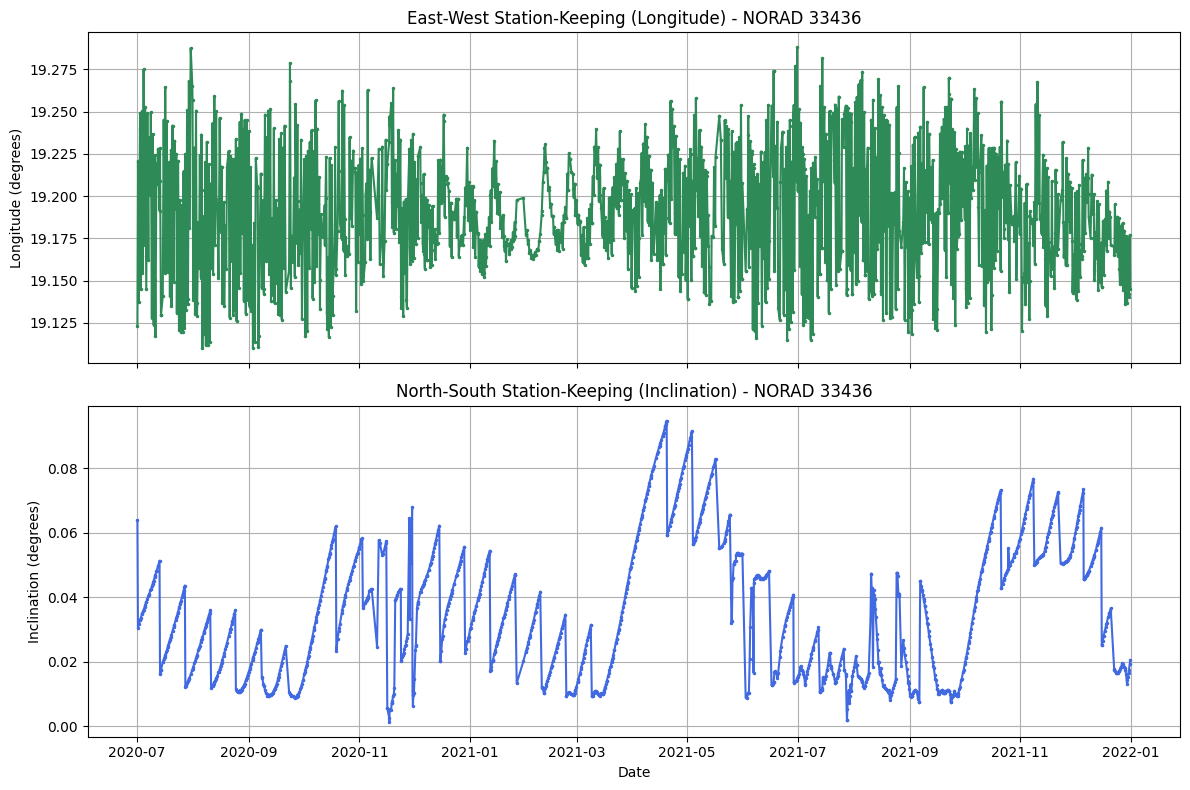

In [10]:
if len(active_sats) > 0:
    sat_active_id = active_sats[0] # Taking the first active satellite
    df_active = df_geo[df_geo['norad_id'] == sat_active_id].sort_values(by='date')
    
    # ZOOM: Filter on a 1.5-year stable period to clearly see the maneuvers
    zoom_start = df_active['date'].min() + pd.DateOffset(months=6)
    zoom_end = zoom_start + pd.DateOffset(months=18)
    df_zoom = df_active[(df_active['date'] >= zoom_start) & (df_active['date'] <= zoom_end)]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Longitude (East-West Station-Keeping)
    ax1.plot(df_zoom['date'], df_zoom['Longitude'], marker='.', linestyle='-', color='seagreen', markersize=3)
    ax1.set_ylabel('Longitude (degrees)')
    ax1.set_title(f'East-West Station-Keeping (Longitude) - NORAD {sat_active_id}')
    ax1.grid(True)
    
    # Inclination (North-South Station-Keeping)
    ax2.plot(df_zoom['date'], df_zoom['Inclination'], marker='.', linestyle='-', color='royalblue', markersize=3)
    ax2.set_ylabel('Inclination (degrees)')
    ax2.set_xlabel('Date')
    ax2.set_title(f'North-South Station-Keeping (Inclination) - NORAD {sat_active_id}')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

### 4. Visualizing a Drifting Satellite
Here, we observe a satellite at the end of its life. Without station-keeping maneuvers, its inclination naturally drifts upwards due to luni-solar gravitational perturbations, and its longitude oscillates freely (a phenomenon known as libration).

### Search for a satellite maintained in position for the example

To illustrate nominal behavior in GEO, we need to isolate a satellite that is actively maintained in position. 
An active GEO satellite has a controlled inclination. We therefore need to filter the dataset to find satellites with an inclination close to 0.

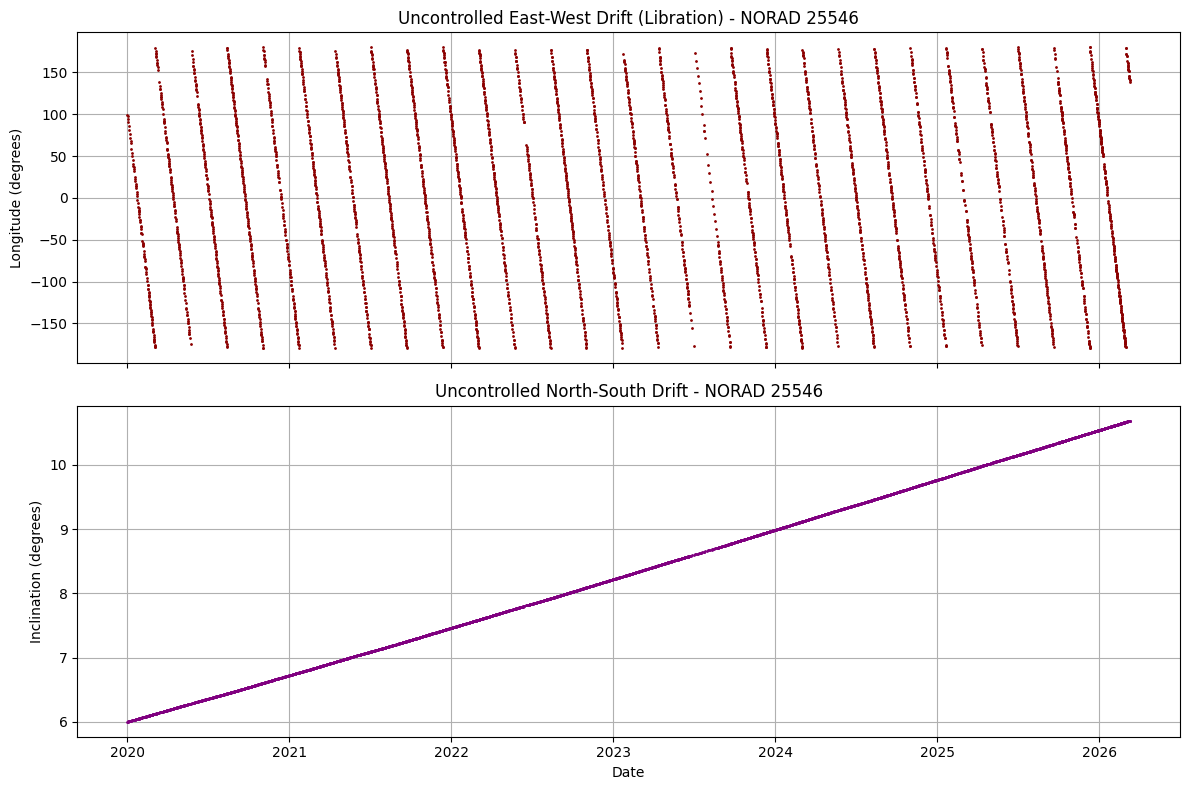

In [11]:
if len(drifting_sats) > 0:
    sat_drift_id = drifting_sats[0] # Taking the first drifting satellite
    df_drift = df_geo[df_geo['norad_id'] == sat_drift_id].sort_values(by='date')
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Longitude (Free Drift / Libration)
    ax1.plot(df_drift['date'], df_drift['Longitude'], marker='.', linestyle='', color='darkred', markersize=2)
    ax1.set_ylabel('Longitude (degrees)')
    ax1.set_title(f'Uncontrolled East-West Drift (Libration) - NORAD {sat_drift_id}')
    ax1.grid(True)
    
    # Inclination (Natural Drift)
    ax2.plot(df_drift['date'], df_drift['Inclination'], marker='.', linestyle='', color='purple', markersize=2)
    ax2.set_ylabel('Inclination (degrees)')
    ax2.set_xlabel('Date')
    ax2.set_title(f'Uncontrolled North-South Drift - NORAD {sat_drift_id}')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

### 5. Dataset Overview
Finally, using our new Longitude-based classification, we can accurately represent the proportion of active versus retired objects within our dataset.

### Overall classification of the dataset

To conclude this exploration, we can automate the detection performed earlier to categorize all the satellites in the dataset.

If a satellite's inclination exceeds 1° during the period studied, it can be considered “Drifting” (probably at the end of its life or in a graveyard orbit). If it remains below 1°, we consider it “Active” (maintained in position).

Distribution of satellites in the dataset:
Drifting (End of life)         10
Maintained at post (Active)     8
Name: count, dtype: int64


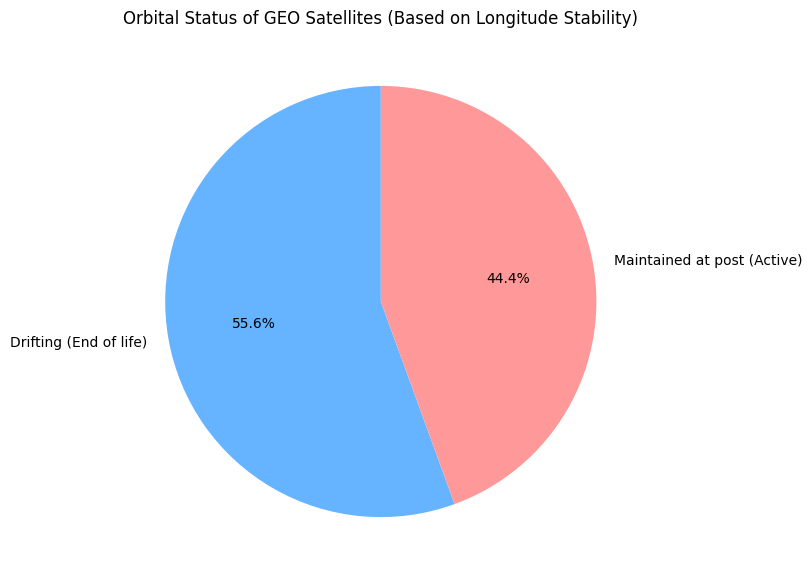

In [12]:
# Create a list mapping the operational status
status_list = ['Maintained at post (Active)'] * len(active_sats) + ['Drifting (End of life)'] * len(drifting_sats)
status_series = pd.Series(status_list)

repartition = status_series.value_counts()

print("Distribution of satellites in the dataset:")
print(repartition)

# Pie Chart
plt.figure(figsize=(7, 7))
repartition.plot.pie(
    autopct='%1.1f%%', 
    colors=['#66b3ff', '#ff9999'], 
    startangle=90, 
    title='Orbital Status of GEO Satellites (Based on Longitude Stability)'
)
plt.ylabel('') 
plt.savefig('pie_chart_status.png', dpi=150, bbox_inches='tight')
plt.show()